In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('test_sample.png')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
# image = cv2.imread('test_sample.png', cv2.IMREAD_GRAYSCALE)
# image_gray = image.copy()

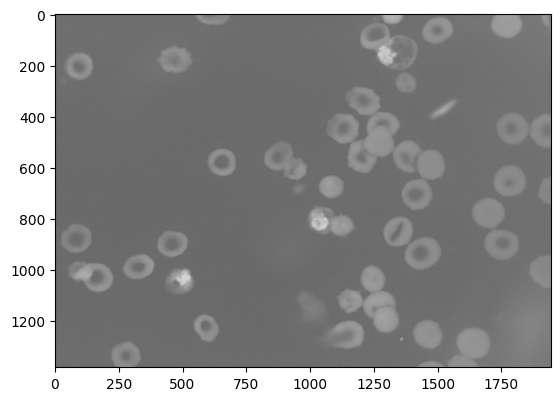

In [3]:
plt.imshow(image, cmap="gray")

In [4]:
ret, thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

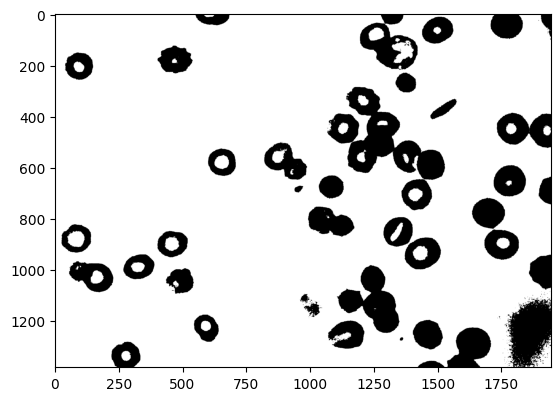

In [5]:
plt.imshow(thresh, cmap="gray")

In [22]:
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=1)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.05 * dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

In [23]:
ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

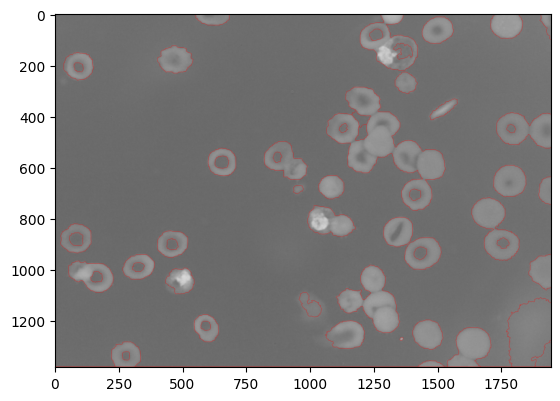

In [24]:
markers = cv2.watershed(image, markers)
img = image.copy()
img[markers == -1] = [255, 0, 0]
plt.imshow(img)